# EEG Preprocessing

1. Load the data and metadata
2. Events and labels
3. Band-pass filtering (1–40 Hz)
4. Notch filter (50 Hz, only if needed)
5. Detect and interpolate bad channels
6. Epoching (downsample + 2 s windows)
7. Independent Component Analysis (ICA)
8. AutoReject (artifact rejection / interpolation)
9. Save the preprocessed data
10. Batch: preprocess all participants

Sections 1–9 are a walkthrough on `sub-01` (with plots); section 10 packages the same pipeline
into a function and runs it over every participant.

In [9]:
import numpy as np
import pandas as pd
import json
from pathlib import Path

import mne
from mne.preprocessing import ICA
from pyprep import NoisyChannels

import matplotlib.pyplot as plt
import pickle

mne.set_log_level("WARNING")

print(np.__version__)

2.4.4


## 1. Load the data and metadata

In [10]:
data_root = Path("data/ds007537")
subject = "sub-01"
eeg_dir = data_root / subject / "eeg"

vhdr_file = eeg_dir / f"{subject}_task-phoneuse_eeg.vhdr"
raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)

print(raw)
print("Sampling rate:", raw.info["sfreq"], "Hz")
print("Channel types:", raw.get_channel_types(unique=True))

<RawBrainVision | sub-01_task-phoneuse_eeg.eeg, 66 x 981160 (981.2 s), ~494.1 MiB, data loaded>
Sampling rate: 1000.0 Hz
Channel types: ['eeg', 'misc']


### Participant metadata and the class label

`participants.tsv` holds demographics and `app_type`

In [11]:
participants = pd.read_csv(data_root / "participants.tsv", sep="\t")
row = participants.loc[participants["participant_id"] == subject].iloc[0]

APP_TYPE_NAMES = {"S": "short_videos", "G": "gaming", "R": "reading"}
app_code = row["app_type"]
smartphone_class = APP_TYPE_NAMES[app_code]

print(f"{subject}: age={row['age']}, sex={row['sex']}, app_type={app_code} -> {smartphone_class}")
print(f"4-class labels for this subject: 'video' and 'smartphone/{smartphone_class}'")

sub-01: age=28, sex=M, app_type=S -> short_videos
4-class labels for this subject: 'video' and 'smartphone/short_videos'


In [12]:
# Build a DigMontage from the BIDS CapTrak electrode positions (units = metres).
elec = pd.read_csv(eeg_dir / f"{subject}_space-CapTrak_electrodes.tsv", sep="\t")
ch_pos = {r["name"]: np.array([r["x"], r["y"], r["z"]], float) for _, r in elec.iterrows()}

with open(eeg_dir / f"{subject}_space-CapTrak_coordsystem.json") as f:
    coords = json.load(f)
fids = coords["AnatomicalLandmarkCoordinates"]

montage = mne.channels.make_dig_montage(
    ch_pos=ch_pos,
    nasion=fids["NAS"],
    lpa=fids["LPA"],
    rpa=fids["RPA"],
    coord_frame="head",
)
raw.set_montage(montage, on_missing="warn")

# Mains frequency 60 Hz (recorded in the US)
raw.info["line_freq"] = 60.0
print("Montage set. EEG channels with positions:",
      sum(t == "eeg" for t in raw.get_channel_types()))

Montage set. EEG channels with positions: 64


/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/2533633779.py:16: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['GSR', 'PPG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, on_missing="warn")


## 2. Events and labels

Markers:


11 = 5 TTL onset pulses before smartphone block

12 = smartphone-block sync markers (every 20 s)

13 = 5 TTL offset pulses ending smartphone block

21 = 5 TTL onset pulses before video block 

22 = video-block sync markers (every 20 s) 

23 = 5 TTL offset pulses ending video block

In [13]:
events_df = pd.read_csv(eeg_dir / f"{subject}_task-phoneuse_events.tsv", sep="\t")

# Keep stimulus markers only and drop the duplicated rows.
stim = (
    events_df[events_df["trial_type"].str.startswith("Stimulus", na=False)]
    .drop_duplicates(subset=["onset", "trial_type", "value", "sample"])
    .reset_index(drop=True)
)
print("Unique stimulus markers per code:")
print(stim["value"].value_counts().sort_index())

Unique stimulus markers per code:
value
11     5
12    30
13     5
21     5
22    15
23     5
Name: count, dtype: int64


In [14]:
# Block spans: onset code -> offset code.
def block_span(onset_code, offset_code):
    start = stim.loc[stim["value"] == onset_code, "onset"].min()
    end = stim.loc[stim["value"] == offset_code, "onset"].max()
    return float(start), float(end)

smart_start, smart_end = block_span(12, 13)   # smartphone use
video_start, video_end = block_span(22, 23)   # video viewing

print(f"Smartphone block: {smart_start:7.1f} - {smart_end:7.1f} s  ({smart_end-smart_start:.0f} s)")
print(f"Video block:      {video_start:7.1f} - {video_end:7.1f} s  ({video_end-video_start:.0f} s)")

# Encode the condition spans as annotations on the raw object. The smartphone label carries
# the subject-specific activity type so a single description fully identifies the class.
block_annot = mne.Annotations(
    onset=[smart_start, video_start],
    duration=[smart_end - smart_start, video_end - video_start],
    description=[f"smartphone/{smartphone_class}", "video"],
)
raw.set_annotations(raw.annotations + block_annot)
print("\nAnnotations now on raw:", set(raw.annotations.description))

Smartphone block:    49.6 -   654.5 s  (605 s)
Video block:        670.3 -   975.2 s  (305 s)

Annotations now on raw: {np.str_('Stimulus/S10001'), np.str_('smartphone/short_videos'), np.str_('Stimulus/S   21'), np.str_('video'), np.str_('Stimulus/S   11'), np.str_('Stimulus/S   23'), np.str_('Stimulus/S   13'), np.str_('Stimulus/S   22'), np.str_('Stimulus/S   12'), np.str_('Stimulus/S99999')}


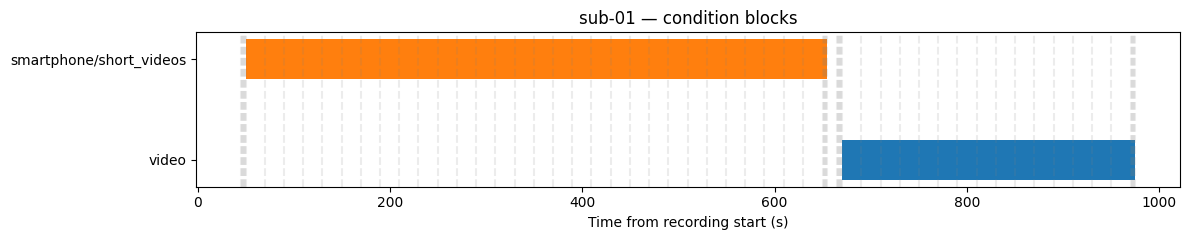

In [15]:
# Visualise the two blocks on the recording timeline.
fig, ax = plt.subplots(figsize=(12, 2.5))
for y, (label, s, e, c) in enumerate([
    ("video", video_start, video_end, "tab:blue"),
    (f"smartphone/{smartphone_class}", smart_start, smart_end, "tab:orange"),
]):
    ax.barh(y, e - s, left=s, height=0.4, color=c, label=label)
for onset in stim["onset"]:
    ax.axvline(onset, ls="--", alpha=0.15, color="grey")
ax.set_yticks([0, 1]); ax.set_yticklabels(["video", f"smartphone/{smartphone_class}"])
ax.set_xlabel("Time from recording start (s)"); ax.set_title(f"{subject} — condition blocks")
plt.tight_layout(); plt.show()

## 3. Band-pass filtering (1–40 Hz)

We split off an **EEG-only** working copy (GSR/PPG are kept aside for the multimodal sub-RQ)
and band-pass filter it to **1–40 Hz**:

* **1 Hz high-pass** removes slow drifts (sweat, electrode settling) and — importantly —
  stabilises ICA, which is sensitive to low-frequency non-stationarity. A 1 Hz high-pass is the
  MNE-recommended setting for fitting ICA.
* **40 Hz low-pass** keeps the delta–gamma range relevant to these cognitive states while
  removing EMG/muscle activity and the 50 Hz mains line.

MNE's default zero-phase FIR (`firwin`) avoids phase distortion.

EEG channels: 64


/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/788288926.py:4: UserWarning: Zero value in spectrum for channel Cz
  psd_before = raw_eeg.compute_psd(fmax=80)
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/788288926.py:6: UserWarning: Zero value in spectrum for channel Cz
  psd_after = raw_eeg.compute_psd(fmax=80)
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/788288926.py:9: UserWarning: Infinite value in PSD for channel Cz.
These channels might be dead.
  psd_before.plot(axes=axes[0], show=False); axes[0].set_title("Before band-pass")
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/788288926.py:10: UserWarning: Infinite value in PSD for channel Cz.
These channels might be dead.
  psd_after.plot(axes=axes[1], show=False); axes[1].set_title("After band-pass (1-40 Hz)")
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/788288926.py:11: UserWarning: This figure includes Axes that are not compatible with 

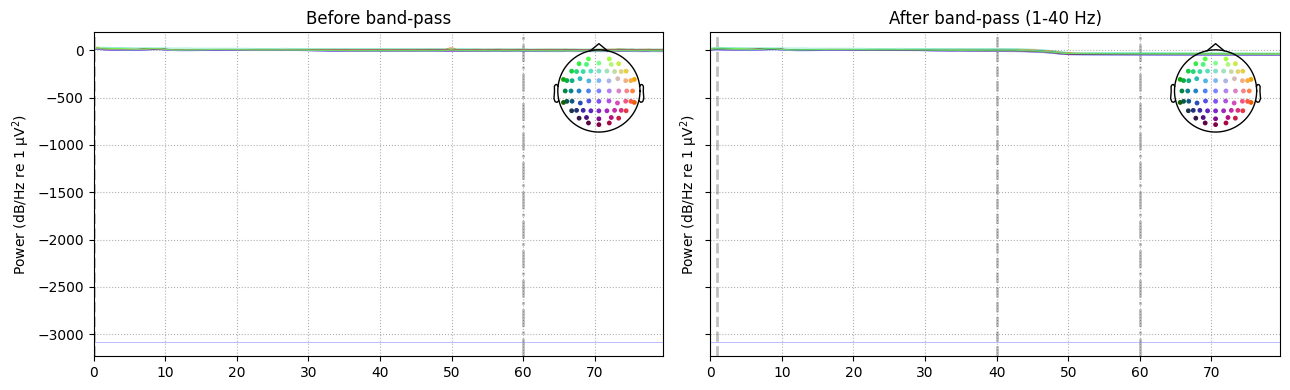

In [16]:
raw_eeg = raw.copy().pick("eeg")
print("EEG channels:", len(raw_eeg.ch_names))

psd_before = raw_eeg.compute_psd(fmax=80)
raw_eeg.filter(l_freq=1.0, h_freq=40.0, fir_design="firwin")
psd_after = raw_eeg.compute_psd(fmax=80)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
psd_before.plot(axes=axes[0], show=False); axes[0].set_title("Before band-pass")
psd_after.plot(axes=axes[1], show=False); axes[1].set_title("After band-pass (1-40 Hz)")
plt.tight_layout(); plt.show()

## 4. Notch filter if needed

In [ ]:
# Estimate whether a 60 Hz line peak survived the 40 Hz low-pass.
psd = raw_eeg.compute_psd(fmax=80)
freqs = psd.freqs

# average over channels
power = psd.get_data().mean(axis=0)

def band_power(f_lo, f_hi):
    m = (freqs >= f_lo) & (freqs <= f_hi)
    return power[m].mean()

# broadband floor below the line frequency
peak_60 = band_power(59, 61)
neighbour = band_power(43, 47)
ratio = peak_60 / neighbour
print(f"60 Hz / neighbouring-band power ratio: {ratio}")

APPLY_NOTCH = ratio > 2.0                       # > 2x neighbours == a real line peak
if APPLY_NOTCH:
    print("Residual line peak detected -> applying 60 Hz notch (+ 120 Hz harmonic).")
    raw_eeg.notch_filter(freqs=[60, 120], fir_design="firwin")
else:
    print("No notable 60 Hz peak after the 40 Hz low-pass -> notch skipped.")

60 Hz / neighbouring-band power ratio: 0.00
No notable 60 Hz peak after the 40 Hz low-pass -> notch skipped.


/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/432298665.py:2: UserWarning: Zero value in spectrum for channel Cz
  psd = raw_eeg.compute_psd(fmax=80)


## 5. Detect and interpolate bad channels

In [18]:
nc = NoisyChannels(raw_eeg, random_state=97)
nc.find_all_bads()          # runs all PREP detection methods incl. RANSAC
bads = nc.get_bads()

print("Bad channels detected:", bads if bads else "none")
raw_eeg.info["bads"] = bads

/Users/marckohler/.pyenv/versions/bci/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bad channels detected: ['CP1', 'C6', 'FC1', 'T8', 'Pz', 'Cz', 'T7', 'F3', 'FT8']


In [19]:
if raw_eeg.info["bads"]:
    raw_eeg.interpolate_bads(reset_bads=True)
    print("Interpolated; remaining bads:", raw_eeg.info["bads"])
else:
    print("No channels to interpolate.")

# Average reference: the recording reference was 'n/a', and an average reference is the
# standard, reference-free choice prior to ICA (and gives ASR/ICA a well-conditioned signal).
raw_eeg.set_eeg_reference("average", projection=False)
print("Applied average reference. EEG channels:", len(raw_eeg.ch_names))

Interpolated; remaining bads: []
Applied average reference. EEG channels: 64


## 6. Epoching

In [20]:
# Downsample to 250 Hz: we already low-passed at 40 Hz, so 250 Hz (Nyquist 125 Hz) loses no
# signal, speeds up ICA/AutoReject ~4x, and shrinks the shared .pkl 4x. 250 Hz is also the
# typical rate for EEGNet-style classification. Guarded so re-running is idempotent.
if raw_eeg.info["sfreq"] > 250:
    raw_eeg.resample(250)
    print("Resampled to", raw_eeg.info["sfreq"], "Hz")

# Cut each condition block into non-overlapping 2 s epochs, tagged with the condition label.
EPOCH_LEN = 2.0
EVENT_ID = {"video": 1, f"smartphone/{smartphone_class}": 2}

def block_epochs(label, start, end):
    block = raw_eeg.copy().crop(tmin=start, tmax=min(end, raw_eeg.times[-1]))
    ep = mne.make_fixed_length_epochs(block, duration=EPOCH_LEN, preload=True)
    ep.events[:, 2] = EVENT_ID[label]      # relabel from make_fixed_length's default code
    ep.event_id = {label: EVENT_ID[label]}
    return ep

epochs = mne.concatenate_epochs([
    block_epochs("video", video_start, video_end),
    block_epochs(f"smartphone/{smartphone_class}", smart_start, smart_end),
])

print(epochs)
print("Epochs per condition:")
for name, code in EVENT_ID.items():
    print(f"  {name:30s} {(epochs.events[:, 2] == code).sum():4d}")

Resampled to 250.0 Hz
<EpochsArray | 454 events (all good), 0 – 1.996 s (baseline off), ~110.9 MiB, data loaded,
 'video': 152
 'smartphone/short_videos': 302>
Epochs per condition:
  video                           152
  smartphone/short_videos         302


/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/1500224507.py:19: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs([


## 7. Independent Component Analysis (ICA)

In [21]:
ica = ICA(
    n_components=0.99,            # keep components explaining 99% variance (clipped to data rank)
    method="infomax",
    fit_params=dict(extended=True),
    max_iter="auto",
    random_state=97,
)
ica.fit(epochs, decim=3)         # fit on the 2 s epochs; decim speeds the fit
print(ica)

<ICA | epochs decomposition, method: infomax (fit in 500 iterations on 75818 samples), 36 ICA components (64 PCA components available), channel types: eeg, no sources marked for exclusion>


Eye-related components: [np.int64(0), np.int64(1)]
Muscle-related components: [7, 8, 10, 11, 13, 15, 16, 18, 19, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35]
Excluding: [np.int64(0), np.int64(1), 7, 8, 10, 11, 13, 15, 16, 18, 19, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35]


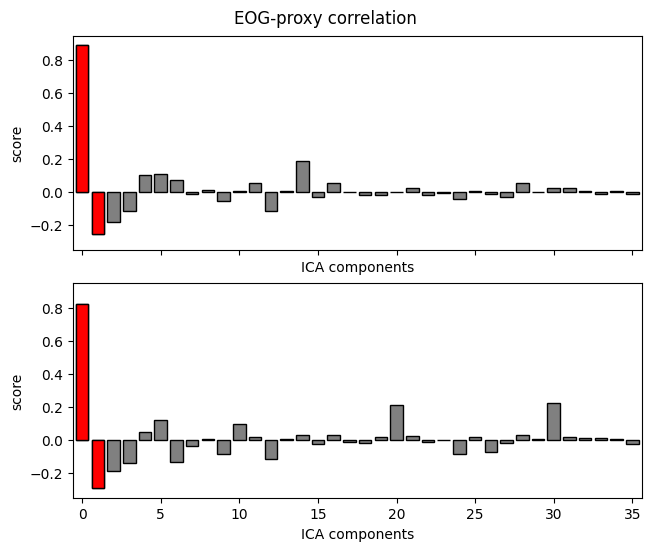

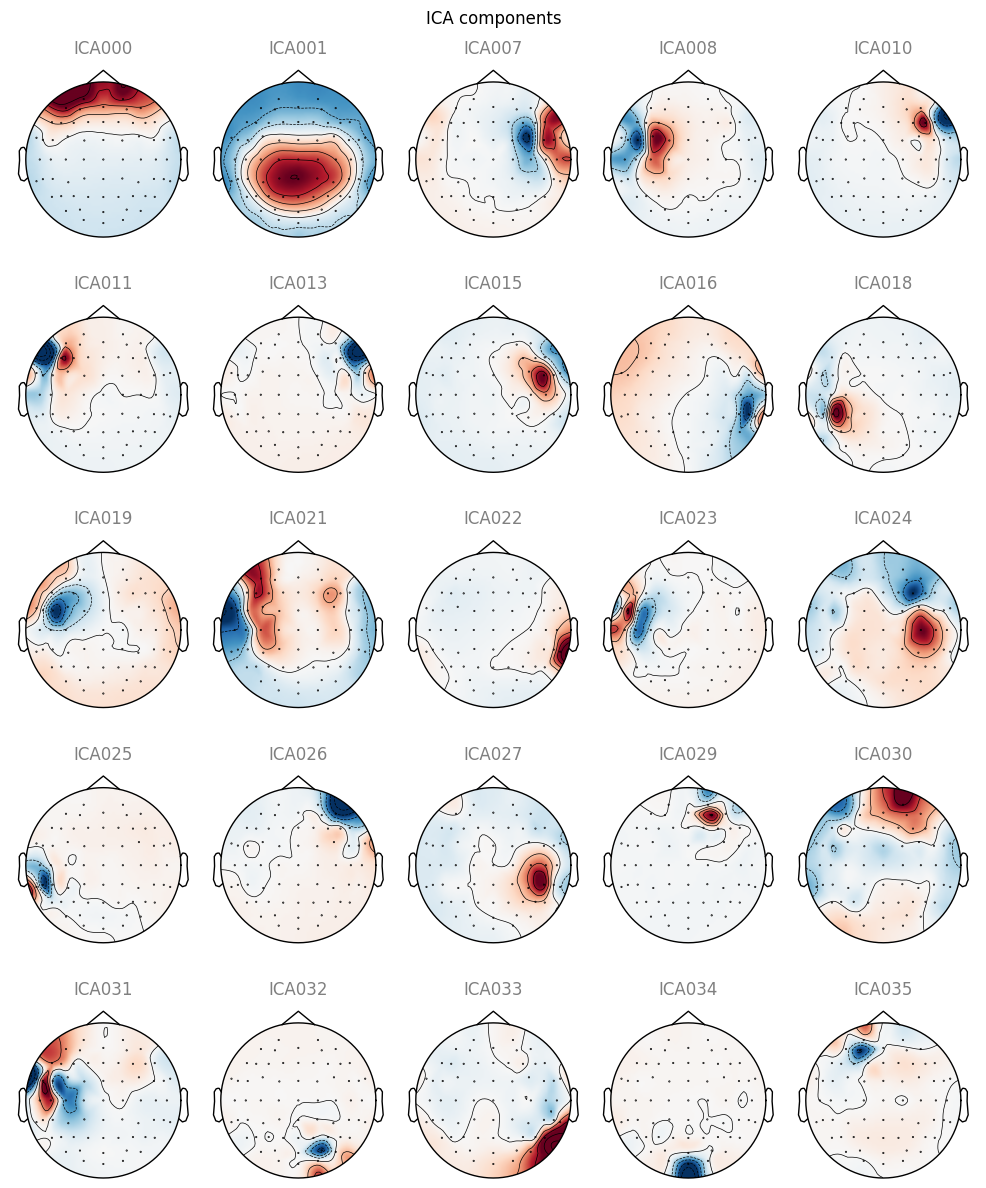

In [22]:
# Eye components via frontal proxy + muscle components.
# Detecting eye components without an EOG channel so we just use the frontal channels
eog_idx, eog_scores = ica.find_bads_eog(epochs, ch_name=["Fp1", "Fp2"])
mus_idx, mus_scores = ica.find_bads_muscle(epochs)

ica.exclude = sorted(set(eog_idx + mus_idx))
print("Eye-related components:", eog_idx)
print("Muscle-related components:", mus_idx)
print("Excluding:", ica.exclude)

if ica.exclude:
    ica.plot_scores(eog_scores, exclude=eog_idx, title="EOG-proxy correlation", show=True)
    ica.plot_components(picks=ica.exclude, show=True)

In [23]:
# Back-project, removing the flagged components -> ICA-cleaned epochs.
epochs_ica = epochs.copy()
ica.apply(epochs_ica)
print(f"ICA applied: removed {len(ica.exclude)} component(s) from {len(epochs_ica)} epochs.")

ICA applied: removed 25 component(s) from 454 epochs.


## 8. AutoReject

/Users/marckohler/.pyenv/versions/bci/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/marckohler/.pyenv/versions/bci/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/marckohler/.pyenv/versions/bci/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/mar

Preprocessing complete.
Epochs: 454 -> 454 (0 rejected)
Window: 2 s @ 250 Hz, 64 channels
ICA removed: 25 component(s)
-------
Epochs per condition (after AutoReject):
    video                           152
    smartphone/short_videos         302


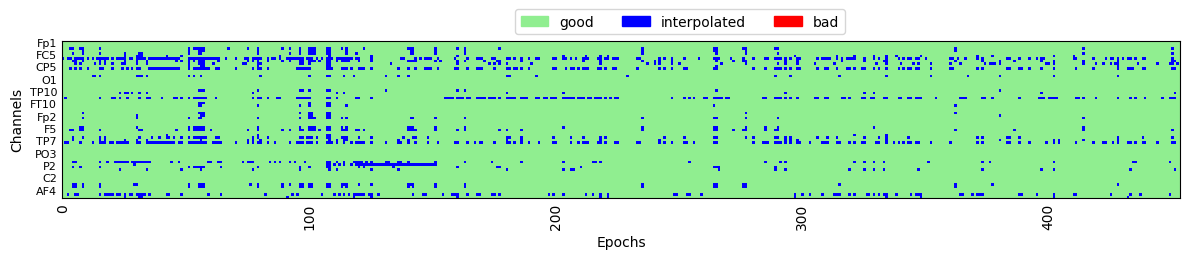

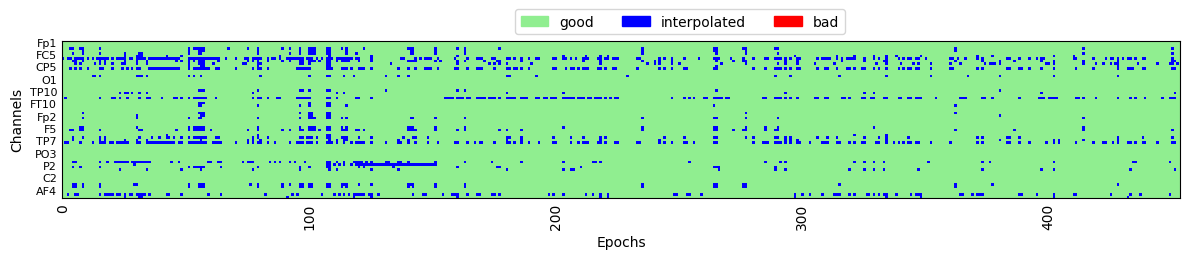

In [25]:
from autoreject import AutoReject

ar = AutoReject(random_state=97, n_jobs=-1, verbose=False)
epochs_clean, reject_log = ar.fit_transform(epochs_ica, return_log=True)

n_before, n_after = len(epochs_ica), len(epochs_clean)
print("Preprocessing complete.")
print(f"Epochs: {n_before} -> {n_after} ({n_before - n_after} rejected)")
print(f"Window: {EPOCH_LEN:.0f} s @ {epochs_clean.info['sfreq']:.0f} Hz, "
      f"{len(epochs_clean.ch_names)} channels")
print(f"ICA removed: {len(ica.exclude)} component(s)")
print('-------')
print("Epochs per condition (after AutoReject):")
for name, code in EVENT_ID.items():
    print(f"    {name:30s} {(epochs_clean.events[:, 2] == code).sum():4d}")

# Visualise which epochs/channels were interpolated (blue) vs rejected (red).
reject_log.plot(orientation="horizontal", show=True)

## 9. Save the preprocessed data

In [26]:
from collections import Counter

# Map each surviving epoch's event code back to its condition label.
code_to_label = {code: name for name, code in EVENT_ID.items()}
labels = [code_to_label[c] for c in epochs_clean.events[:, 2]]

preprocessed = {
    "subject": subject,
    "data": epochs_clean.get_data().astype(np.float32),  # (n_epochs, n_channels, n_samples), volts
    "labels": labels,                                    # condition label per epoch
    "ch_names": epochs_clean.ch_names,
    "sfreq": float(epochs_clean.info["sfreq"]),
    "epoch_length_s": EPOCH_LEN,
    "event_id": EVENT_ID,
    "app_type": app_code,
    "smartphone_class": smartphone_class,
    "bad_channels_interpolated": bads,
    "ica_excluded": list(ica.exclude),
}

out_path = data_root / f"{subject}_preprocessed.pkl"
with open(out_path, "wb") as f:
    pickle.dump(preprocessed, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved -> {out_path}  ({out_path.stat().st_size / 1e6:.1f} MB)")
print(f"  data shape : {preprocessed['data'].shape}  (epochs x channels x samples)")
print(f"  labels     : {dict(Counter(labels))}")

# MNE-native alternative (preserves the full Epochs object; requires MNE to reload):
# epochs_clean.save(data_root / f"{subject}_clean-epo.fif", overwrite=True)

Saved -> data/ds007537/sub-01_preprocessed.pkl  (58.1 MB)
  data shape : (454, 64, 500)  (epochs x channels x samples)
  labels     : {'video': 152, 'smartphone/short_videos': 302}


## 10. Batch processing all participants

In [29]:
from autoreject import AutoReject


def preprocess_subject(subject, epoch_len=2.0):
    """Run the full pipeline (sections 1-8, no plots) for one subject.

    Returns (epochs_clean, result_dict). Mirrors the sub-01 walkthrough exactly.
    """
    eeg_dir = data_root / subject / "eeg"

    # 1. Load + montage + class label
    raw = mne.io.read_raw_brainvision(eeg_dir / f"{subject}_task-phoneuse_eeg.vhdr", preload=True)
    row = participants.loc[participants["participant_id"] == subject].iloc[0]
    app_code = row["app_type"]
    smartphone_class = APP_TYPE_NAMES[app_code]

    elec = pd.read_csv(eeg_dir / f"{subject}_space-CapTrak_electrodes.tsv", sep="\t")
    ch_pos = {r["name"]: np.array([r["x"], r["y"], r["z"]], float) for _, r in elec.iterrows()}
    with open(eeg_dir / f"{subject}_space-CapTrak_coordsystem.json") as f:
        fids = json.load(f)["AnatomicalLandmarkCoordinates"]
    montage = mne.channels.make_dig_montage(
        ch_pos=ch_pos, nasion=fids["NAS"], lpa=fids["LPA"], rpa=fids["RPA"], coord_frame="head")
    raw.set_montage(montage, on_missing="warn")
    raw.info["line_freq"] = 60.0          # recorded in the US -> 60 Hz mains

    # 2. Condition block spans (onset code -> offset code)
    events_df = pd.read_csv(eeg_dir / f"{subject}_task-phoneuse_events.tsv", sep="\t")
    stim = (events_df[events_df["trial_type"].str.startswith("Stimulus", na=False)]
            .drop_duplicates(subset=["onset", "trial_type", "value", "sample"]).reset_index(drop=True))
    def span(onset_code, offset_code):
        return (float(stim.loc[stim["value"] == onset_code, "onset"].min()),
                float(stim.loc[stim["value"] == offset_code, "onset"].max()))
    smart_start, smart_end = span(12, 13)
    video_start, video_end = span(22, 23)

    # 3. Band-pass (EEG only, 1-40 Hz)
    raw_eeg = raw.copy().pick("eeg")
    raw_eeg.filter(l_freq=1.0, h_freq=40.0, fir_design="firwin")

    # 4. Notch only if a 60 Hz line peak survived the low-pass
    psd = raw_eeg.compute_psd(fmax=80)
    freqs, power = psd.freqs, psd.get_data().mean(axis=0)
    band = lambda lo, hi: power[(freqs >= lo) & (freqs <= hi)].mean()
    if band(59, 61) / band(43, 47) > 2.0:
        raw_eeg.notch_filter(freqs=[60, 120], fir_design="firwin")

    # 5. Bad channels -> interpolate -> average reference
    nc = NoisyChannels(raw_eeg, random_state=97)
    nc.find_all_bads()
    bads = nc.get_bads()
    raw_eeg.info["bads"] = bads
    if bads:
        raw_eeg.interpolate_bads(reset_bads=True)
    raw_eeg.set_eeg_reference("average", projection=False)

    # 6. Downsample to 250 Hz + 2 s epochs labelled by condition
    if raw_eeg.info["sfreq"] > 250:
        raw_eeg.resample(250)
    event_id = {"video": 1, f"smartphone/{smartphone_class}": 2}
    def block_epochs(label, start, end):
        block = raw_eeg.copy().crop(tmin=start, tmax=min(end, raw_eeg.times[-1]))
        ep = mne.make_fixed_length_epochs(block, duration=epoch_len, preload=True)
        ep.events[:, 2] = event_id[label]
        ep.event_id = {label: event_id[label]}
        return ep
    epochs = mne.concatenate_epochs([
        block_epochs("video", video_start, video_end),
        block_epochs(f"smartphone/{smartphone_class}", smart_start, smart_end),
    ])

    # 7. ICA artifact removal (EOG proxy Fp1/Fp2 + muscle)
    ica = ICA(n_components=0.99, method="infomax", fit_params=dict(extended=True),
              max_iter="auto", random_state=97)
    ica.fit(epochs, decim=3)
    eog_idx, _ = ica.find_bads_eog(epochs, ch_name=["Fp1", "Fp2"])
    mus_idx, _ = ica.find_bads_muscle(epochs)
    ica.exclude = sorted(set(eog_idx + mus_idx))
    epochs_ica = epochs.copy()
    ica.apply(epochs_ica)

    # 8. AutoReject (per-epoch interpolation / rejection)
    ar = AutoReject(random_state=97, n_jobs=-1, verbose=False)
    epochs_clean = ar.fit_transform(epochs_ica)

    code_to_label = {c: n for n, c in event_id.items()}
    labels = [code_to_label[c] for c in epochs_clean.events[:, 2]]
    result = {
        "subject": subject,
        "data": epochs_clean.get_data().astype(np.float32),   # (n_epochs, n_channels, n_samples)
        "labels": labels,
        "ch_names": epochs_clean.ch_names,
        "sfreq": float(epochs_clean.info["sfreq"]),
        "epoch_length_s": epoch_len,
        "event_id": event_id,
        "app_type": app_code,
        "smartphone_class": smartphone_class,
        "bad_channels_interpolated": bads,
        "ica_excluded": list(ica.exclude),
    }
    return epochs_clean, result

In [30]:
SUBJECTS = sorted(p.name for p in data_root.glob("sub-*") if p.is_dir())
# SUBJECTS = SUBJECTS[:2]    # uncomment to smoke-test on a couple of subjects first

results, failed = {}, {}
for s in SUBJECTS:
    print(f"=== {s} ===", flush=True)
    try:
        _, res = preprocess_subject(s)
        with open(data_root / f"{s}_preprocessed.pkl", "wb") as f:
            pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)
        results[s] = res
        print(f"  ok: {res['data'].shape}  bads={res['bad_channels_interpolated']}  "
              f"ICs_excluded={res['ica_excluded']}", flush=True)
    except Exception as e:
        failed[s] = repr(e)
        print(f"  FAILED: {e!r}", flush=True)

print(f"\nDone: {len(results)} ok, {len(failed)} failed.")
for s, err in failed.items():
    print(f"  {s}: {err}")

=== sub-01 ===


/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:23: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['GSR', 'PPG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, on_missing="warn")
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:41: UserWarning: Zero value in spectrum for channel Cz
  psd = raw_eeg.compute_psd(fmax=80)
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:66: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs([
/Users/marckohler/.pyenv/versions/bci/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_va

  ok: (454, 64, 500)  bads=['CP1', 'C6', 'FC1', 'T8', 'Pz', 'Cz', 'T7', 'F3', 'FT8']  ICs_excluded=[np.int64(0), np.int64(1), 7, 8, 10, 11, 13, 15, 16, 18, 19, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35]
=== sub-02 ===


/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:23: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['GSR', 'PPG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, on_missing="warn")
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:41: UserWarning: Zero value in spectrum for channel Cz
  psd = raw_eeg.compute_psd(fmax=80)
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:66: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs([
/Users/marckohler/.pyenv/versions/bci/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_va

  ok: (424, 64, 500)  bads=['CP1', 'C1', 'Cz', 'FC3', 'PO3']  ICs_excluded=[np.int64(0), np.int64(2), np.int64(3), 5, 6, 8, 11, 12, 13, 15, 16, 18, 19, 22, 25, 26, 27, 28, 32, 34, 36, 37, 39, 41]
=== sub-03 ===


...

  ok: (454, 64, 500)  bads=['TP7', 'POz', 'F6', 'F2', 'C3', 'FT8', 'AF7', 'P1', 'Cz', 'C1', 'FT7', 'C2', 'P8', 'TP8', 'TP10', 'C5', 'F5']  ICs_excluded=[np.int64(0), 1, 9, 10, 13, 14, 15, 17, 18, 19, 21, 29, 30]
=== sub-22 ===


/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:23: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['GSR', 'PPG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, on_missing="warn")
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:41: UserWarning: Zero value in spectrum for channel Cz
  psd = raw_eeg.compute_psd(fmax=80)
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:66: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs([
/Users/marckohler/.pyenv/versions/bci/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_va

  ok: (377, 64, 500)  bads=[np.str_('FT10'), 'TP7', 'PO7', np.str_('C6'), np.str_('P2'), 'Pz', 'Cz', 'C1', 'CPz', 'C2', np.str_('CP6'), np.str_('FC6'), np.str_('C5'), 'TP10', 'C3', 'F5']  ICs_excluded=[np.int64(10), 15]
=== sub-23 ===


/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:23: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['GSR', 'PPG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, on_missing="warn")
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:41: UserWarning: Zero value in spectrum for channel Cz
  psd = raw_eeg.compute_psd(fmax=80)
/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_24051/3806554619.py:66: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs([
/Users/marckohler/.pyenv/versions/bci/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_va

  ok: (454, 64, 500)  bads=['TP7', 'CP1', 'Fp1', 'Pz', 'Cz', 'CP2', 'TP8', 'C3']  ICs_excluded=[np.int64(0), np.int64(1), 2, 8, np.int64(10), 11, 12, 13, 14, 15, 18, 19, 20, 22, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36]

Done: 22 ok, 1 failed.
  sub-11: RuntimeError('One PCA component captures most of the explained variance (99.63772437999995%), your threshold results in 1 component. You should select a higher value.')


In [32]:
# Stack every participant into one labelled dataset — the 4-class scheme
# (video + smartphone/{short_videos,gaming,reading}). `groups` enables subject-wise CV.
from collections import Counter

assert results, "No subjects processed successfully — see the 'failed' report above."

X = np.concatenate([r["data"] for r in results.values()], axis=0)
y = np.array([lbl for r in results.values() for lbl in r["labels"]])
groups = np.array([r["subject"] for r in results.values() for _ in r["labels"]])

combined = {
    "X": X,                                    # (n_epochs, n_channels, n_samples), float32
    "y": y,                                     # condition label per epoch
    "groups": groups,                           # subject id per epoch (for GroupKFold / LOSO)
    "ch_names": next(iter(results.values()))["ch_names"],
    "sfreq": next(iter(results.values()))["sfreq"],
    "classes": sorted(set(y.tolist())),
}
print("Combined dataset:", X.shape, f"(~{X.nbytes / 1e9:.2f} GB in memory)")
print("Classes:", combined["classes"])
print("Per-class epochs:", dict(Counter(y.tolist())))

with open(data_root / "all_subjects_preprocessed.pkl", "wb") as f:
    pickle.dump(combined, f, protocol=pickle.HIGHEST_PROTOCOL)

Combined dataset: (9642, 64, 500) (~1.23 GB in memory)
Classes: ['smartphone/gaming', 'smartphone/reading', 'smartphone/short_videos', 'video']
Per-class epochs: {'video': 3192, 'smartphone/short_videos': 4095, 'smartphone/gaming': 1781, 'smartphone/reading': 574}
